In [35]:
from sklearn import linear_model
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [4]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
from sklearn.preprocessing import OneHotEncoder

#  TWO TYPES OF ENCODING 

  1. ONEHOT ENCODING
  2. LABEL ENCODING

# ONEHOT ENCODING

In [5]:
data=pd.read_csv('homeprice_onehot_ML.csv')
data

,town,area,price
0,monroe township,2600,550000
1,monroe township,3000,565000
2,monroe township,3200,61000
3,monroe township,3600,680000
4,monroe township,4000,725000
5,west windsor,2600,585000
6,west windsor,2800,615000
7,west windsor,3300,650000
8,west windsor,3600,710000
9,robbinsville,2600,575000


In [6]:
data.head()

,town,area,price
0,monroe township,2600,550000
1,monroe township,3000,565000
2,monroe township,3200,61000
3,monroe township,3600,680000
4,monroe township,4000,725000


In [7]:
data.tail()

,town,area,price
8,west windsor,3600,710000
9,robbinsville,2600,575000
10,robbinsville,2900,600000
11,robbinsville,3100,620000
12,robbinsville,3600,695000


In [8]:
data.dtypes

town       str
area     int64
price    int64
dtype: object

In [9]:
data.isna().sum()

town     0
area     0
price    0
dtype: int64

In [11]:
data.duplicated().sum()

np.int64(0)

In [13]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   town    13 non-null     str  
 1   area    13 non-null     int64
 2   price   13 non-null     int64
dtypes: int64(2), str(1)
memory usage: 444.0 bytes


In [14]:
data.describe()

,area,price
count,13.000000,13.000000
mean,3146.153846,587000.000000
std,453.900475,168120.492505
min,2600.000000,61000.000000
25%,2800.000000,575000.000000
50%,3100.000000,615000.000000
75%,3600.000000,680000.000000
max,4000.000000,725000.000000


In [15]:
data.area.unique()

array([2600, 3000, 3200, 3600, 4000, 2800, 3300, 2900, 3100])

In [16]:
data.price.unique()

array([550000, 565000,  61000, 680000, 725000, 585000, 615000, 650000,
       710000, 575000, 600000, 620000, 695000])

In [17]:
correlation=data[['area','price']].corr()
correlation

,area,price
area,1.000000,0.287097
price,0.287097,1.000000


<Axes: >

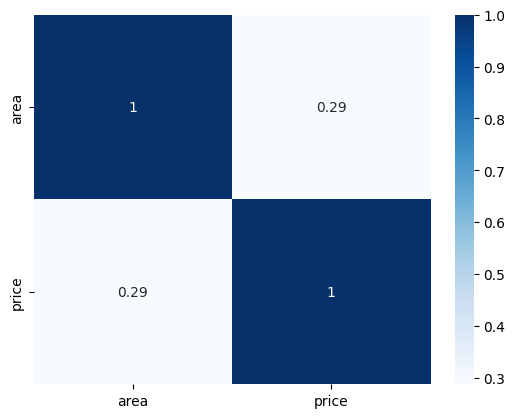

In [19]:
sns.heatmap(correlation,annot=True,cmap='Blues')

In [20]:
dummies=pd.get_dummies(data.town,dtype=int)
dummies

,monroe township,robbinsville,west windsor
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0
5,0,0,1
6,0,0,1
7,0,0,1
8,0,0,1
9,0,1,0


In [22]:
newdata=pd.concat([data,dummies],axis=1)
newdata

,town,area,price,monroe township,robbinsville,west windsor
0,monroe township,2600,550000,1,0,0
1,monroe township,3000,565000,1,0,0
2,monroe township,3200,61000,1,0,0
3,monroe township,3600,680000,1,0,0
4,monroe township,4000,725000,1,0,0
5,west windsor,2600,585000,0,0,1
6,west windsor,2800,615000,0,0,1
7,west windsor,3300,650000,0,0,1
8,west windsor,3600,710000,0,0,1
9,robbinsville,2600,575000,0,1,0


In [42]:
a=newdata.drop('town',axis=1)
a


,area,price,monroe township,robbinsville,west windsor
0,2600,550000,1,0,0
1,3000,565000,1,0,0
2,3200,61000,1,0,0
3,3600,680000,1,0,0
4,4000,725000,1,0,0
5,2600,585000,0,0,1
6,2800,615000,0,0,1
7,3300,650000,0,0,1
8,3600,710000,0,0,1
9,2600,575000,0,1,0


In [44]:
x=a.drop('price',axis=1)
x.columns=x.columns.astype(str)
x

,area,monroe township,robbinsville,west windsor
0,2600,1,0,0
1,3000,1,0,0
2,3200,1,0,0
3,3600,1,0,0
4,4000,1,0,0
5,2600,0,0,1
6,2800,0,0,1
7,3300,0,0,1
8,3600,0,0,1
9,2600,0,1,0


In [45]:
y=a['price']
y

0     550000
1     565000
2      61000
3     680000
4     725000
5     585000
6     615000
7     650000
8     710000
9     575000
10    600000
11    620000
12    695000
Name: price, dtype: int64

In [46]:
model=LinearRegression()
model.fit(x,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ 145.78,-97838.64, 41991.61, 55847.02]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['area','monroe township','robbinsville','west windsor']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.359e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,3


In [47]:
y_pred=model.predict(x)
y_pred

array([417067.08234795, 475380.56331973, 504537.30380563, 562850.78477741,
       621164.2657492 , 570752.74134601, 599909.48183191, 672801.33304664,
       716536.44377548, 556897.33390675, 600632.44463559, 629789.18512148,
       702681.03633622])

In [48]:
result=pd.DataFrame({'actual price':y,
                     'predicted price':y_pred})
result

,actual price,predicted price
0,550000,417067.082348
1,565000,475380.563320
2,61000,504537.303806
3,680000,562850.784777
4,725000,621164.265749
5,585000,570752.741346
6,615000,599909.481832
7,650000,672801.333047
8,710000,716536.443775
9,575000,556897.333907


In [49]:
model.score(x,y)

0.26760244239734743

In [ ]:
#MSE
from sklearn.metrics import mean_squared_error
mean_squared_error(y,y_pred)

19108477630.947853

In [ ]:
#MAE
import numpy as np
print(np.sqrt(mean_absolute_error(y,y_pred)))

274.8363839761437


In [52]:
#RMSE
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y,y_pred)

75535.03795708228

In [54]:
model.predict([[3900,1,0,1]])

c:\Users\adith\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([662432.91765203])

##  ANOTHER METHOD FOR ENCODING

In [55]:
enc=OneHotEncoder()

In [57]:
enc.fit_transform(data[['town']])

#this method fits the encoder to data and then transform it.fitting means Learning the unique categories and 
#transforming means converting this catogories into numerical value

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 13 stored elements and shape (13, 3)>

In [59]:
enc.fit_transform(data[['town']]).toarray()
#convert the resulting sparse matrix into a dense numpy array

array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.]])

In [61]:
enc_data=pd.DataFrame(enc.fit_transform(data[['town']]).toarray())
enc_data

,0,1,2
0,1.0,0.0,0.0
1,1.0,0.0,0.0
2,1.0,0.0,0.0
3,1.0,0.0,0.0
4,1.0,0.0,0.0
5,0.0,0.0,1.0
6,0.0,0.0,1.0
7,0.0,0.0,1.0
8,0.0,0.0,1.0
9,0.0,1.0,0.0


In [62]:
onehot_data=data.join(enc_data)
onehot_data

,town,area,price,0,1,2
0,monroe township,2600,550000,1.0,0.0,0.0
1,monroe township,3000,565000,1.0,0.0,0.0
2,monroe township,3200,61000,1.0,0.0,0.0
3,monroe township,3600,680000,1.0,0.0,0.0
4,monroe township,4000,725000,1.0,0.0,0.0
5,west windsor,2600,585000,0.0,0.0,1.0
6,west windsor,2800,615000,0.0,0.0,1.0
7,west windsor,3300,650000,0.0,0.0,1.0
8,west windsor,3600,710000,0.0,0.0,1.0
9,robbinsville,2600,575000,0.0,1.0,0.0


In [63]:
xy=onehot_data.drop('town',axis=1)
xy

,area,price,0,1,2
0,2600,550000,1.0,0.0,0.0
1,3000,565000,1.0,0.0,0.0
2,3200,61000,1.0,0.0,0.0
3,3600,680000,1.0,0.0,0.0
4,4000,725000,1.0,0.0,0.0
5,2600,585000,0.0,0.0,1.0
6,2800,615000,0.0,0.0,1.0
7,3300,650000,0.0,0.0,1.0
8,3600,710000,0.0,0.0,1.0
9,2600,575000,0.0,1.0,0.0


In [65]:
x=xy.drop('price',axis=1)
x.columns=x.columns.astype(str)

x

,area,0,1,2
0,2600,1.0,0.0,0.0
1,3000,1.0,0.0,0.0
2,3200,1.0,0.0,0.0
3,3600,1.0,0.0,0.0
4,4000,1.0,0.0,0.0
5,2600,0.0,0.0,1.0
6,2800,0.0,0.0,1.0
7,3300,0.0,0.0,1.0
8,3600,0.0,0.0,1.0
9,2600,0.0,1.0,0.0


In [66]:
y=onehot_data['price']
y

0     550000
1     565000
2      61000
3     680000
4     725000
5     585000
6     615000
7     650000
8     710000
9     575000
10    600000
11    620000
12    695000
Name: price, dtype: int64

In [67]:
model=LinearRegression()
model.fit(x,y)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ 145.78,-97838.64, 41991.61, 55847.02]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['area','0','1','2']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.359e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,3


In [68]:
y_pred1=model.predict(x)
y_pred1

array([417067.08234795, 475380.56331973, 504537.30380563, 562850.78477741,
       621164.2657492 , 570752.74134601, 599909.48183191, 672801.33304664,
       716536.44377548, 556897.33390675, 600632.44463559, 629789.18512148,
       702681.03633622])

In [69]:
result1=pd.DataFrame({'actual price': y,
                      'predicted price': y_pred1})

result1

,actual price,predicted price
0,550000,417067.082348
1,565000,475380.563320
2,61000,504537.303806
3,680000,562850.784777
4,725000,621164.265749
5,585000,570752.741346
6,615000,599909.481832
7,650000,672801.333047
8,710000,716536.443775
9,575000,556897.333907


In [70]:
model.score(x,y)

0.26760244239734743

In [ ]:
mean_squared_error(y,y_pred1)  #MSE

19108477630.947853

In [72]:
print(np.sqrt(mean_squared_error(y,y_pred1)))

138233.41720057366


In [73]:
mean_absolute_error(y,y_pred1)

75535.03795708228

In [74]:
model.predict([[39000,1,0,1]])

c:\Users\adith\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([5779440.87292618])

# LABEL ENCODING

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import warnings
warnings.filterwarnings('ignore')

from sklearn import linear_model
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

from sklearn.preprocessing import LabelEncoder



In [3]:
data=pd.read_csv('homeprice_onehot_ML.csv')
data

,town,area,price
0,monroe township,2600,550000
1,monroe township,3000,565000
2,monroe township,3200,61000
3,monroe township,3600,680000
4,monroe township,4000,725000
5,west windsor,2600,585000
6,west windsor,2800,615000
7,west windsor,3300,650000
8,west windsor,3600,710000
9,robbinsville,2600,575000


In [4]:
data.head()

,town,area,price
0,monroe township,2600,550000
1,monroe township,3000,565000
2,monroe township,3200,61000
3,monroe township,3600,680000
4,monroe township,4000,725000


In [5]:
data.tail()

,town,area,price
8,west windsor,3600,710000
9,robbinsville,2600,575000
10,robbinsville,2900,600000
11,robbinsville,3100,620000
12,robbinsville,3600,695000


In [9]:
data.duplicated().sum()

np.int64(0)

In [10]:
data.isna().sum()

town     0
area     0
price    0
dtype: int64

In [11]:
data.info

<bound method DataFrame.info of                town  area   price
0   monroe township  2600  550000
1   monroe township  3000  565000
2   monroe township  3200   61000
3   monroe township  3600  680000
4   monroe township  4000  725000
5      west windsor  2600  585000
6      west windsor  2800  615000
7      west windsor  3300  650000
8      west windsor  3600  710000
9      robbinsville  2600  575000
10     robbinsville  2900  600000
11     robbinsville  3100  620000
12     robbinsville  3600  695000>

In [12]:
data.dtypes

town       str
area     int64
price    int64
dtype: object

In [13]:
data.describe

<bound method NDFrame.describe of                town  area   price
0   monroe township  2600  550000
1   monroe township  3000  565000
2   monroe township  3200   61000
3   monroe township  3600  680000
4   monroe township  4000  725000
5      west windsor  2600  585000
6      west windsor  2800  615000
7      west windsor  3300  650000
8      west windsor  3600  710000
9      robbinsville  2600  575000
10     robbinsville  2900  600000
11     robbinsville  3100  620000
12     robbinsville  3600  695000>

In [14]:
correlation=data[['area','price']].corr()
correlation

,area,price
area,1.000000,0.287097
price,0.287097,1.000000


<Axes: >

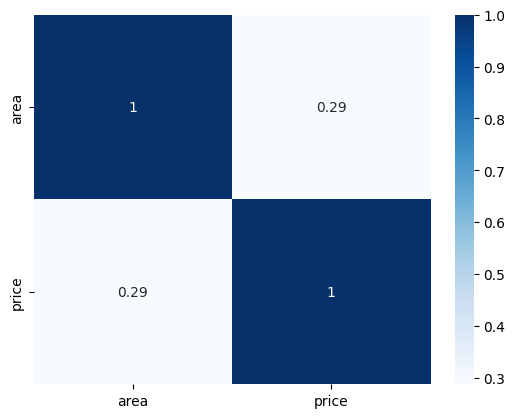

In [15]:
sns.heatmap(correlation,annot=True,cmap='Blues')

In [18]:
#label encoding module

lb=LabelEncoder()
data['town']=lb.fit_transform(data['town'])
data[['town']]

#in label encoding we dont need to join it sepreatly.

,town
0,0
1,0
2,0
3,0
4,0
5,2
6,2
7,2
8,2
9,1


In [19]:
data.head()

,town,area,price
0,0,2600,550000
1,0,3000,565000
2,0,3200,61000
3,0,3600,680000
4,0,4000,725000


In [21]:
x=data.drop('price',axis=1)
x

,town,area
0,0,2600
1,0,3000
2,0,3200
3,0,3600
4,0,4000
5,2,2600
6,2,2800
7,2,3300
8,2,3600
9,1,2600


In [22]:
y=data['price']
y

0     550000
1     565000
2      61000
3     680000
4     725000
5     585000
6     615000
7     650000
8     710000
9     575000
10    600000
11    620000
12    695000
Name: price, dtype: int64

In [23]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3)

In [24]:
model=LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[112869.69, 146.19]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['town','area']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.444e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,2


In [25]:
x_test

,town,area
0,0,2600
11,1,3100
10,1,2900
4,0,4000


In [26]:
model.predict([[0,39000]])

array([5687096.63250366])

In [27]:
model.score(x_test,y_test)

-3.2167202841736238

In [28]:
#predictions

predicted_value=model.predict(x_test)
predicted_value

array([365661.78623719, 551628.11127379, 522389.45827233, 570332.35724744])

In [30]:
#method2

r2=r2_score(y_test,predicted_value)
r2

-3.2167202841736238

In [32]:
model.coef_

array([112869.69253294,    146.19326501])

In [33]:
model.intercept_

np.float64(-14440.702781844768)

In [35]:
result1=pd.DataFrame({
    'Actual_price':y_test,
    "predicted_value":predicted_value
})
result1

,Actual_price,predicted_value
0,550000,365661.786237
11,620000,551628.111274
10,600000,522389.458272
4,725000,570332.357247


In [42]:
a=(mean_squared_error(y_test,predicted_value))
a


17150192030.78741

In [40]:
print(mean_absolute_error(y_test,predicted_value))


121247.07174231324


In [43]:
print(np.sqrt(a))

130958.74171198886


In [44]:
print('conclusions')
if r2>0.9:
    print(f'The model performs excellently with an R-squred value of {r2:4f}.it explains pvber 90% of the varience in the target variable')
else:
    print(f'The model performs moderate with an R-squred value of {r2:4f}.consider improving the model by adding more feature or using more advantage or using more advanced techniques')


conclusions
The model performs moderate with an R-squred value of -3.216720.consider improving the model by adding more feature or using more advantage or using more advanced techniques
